# Abstract Figure Field Panels

This notebook exports standalone field visualizations for a single sample,
using the same field data and publication styling already used in the repo.
The intended workflow is:

1. Point `traj_path` at a decoded trajectory bundle.
2. Pick one sample from that bundle.
3. Run the notebook.
4. Insert the exported PNG/PDF panels into Keynote manually.

The notebook writes:
- one standalone image per reference field and marginal time
- one horizontal strip of reference fields across marginal times


In [49]:
from __future__ import annotations

import importlib
import json
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.figure import Figure

if "__file__" in globals():
    REPO_ROOT = Path(__file__).resolve().parent.parent
else:
    cwd = Path.cwd().resolve()
    if (cwd / "mmsfm").exists():
        REPO_ROOT = cwd
    elif (cwd.parent / "mmsfm").exists():
        REPO_ROOT = cwd.parent
    else:
        REPO_ROOT = cwd

print(f"REPO_ROOT: {REPO_ROOT}")

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

load_training_time_data_naive = importlib.import_module(
    "mmsfm.fae.multiscale_dataset_naive"
).load_training_time_data_naive
load_transform_info = importlib.import_module(
    "data.transform_utils"
).load_transform_info
apply_inverse_transform = importlib.import_module(
    "data.transform_utils"
).apply_inverse_transform
format_for_paper = importlib.import_module(
    "scripts.images.field_visualization"
).format_for_paper

format_for_paper()


REPO_ROOT: /data1/jy384/research/MMSFM


## Configuration

`sample_position` is the reference sample index inside the dataset split used
by the FAE/CSP experiment metadata. For the current CSP run this is the train
split of `fae_tran_inclusions_minmax`.


In [50]:
traj_path = Path(
    os.environ.get(
        "TRAJ_PATH",
        "/data1/jy384/research/MMSFM/results/csp/transformer_patch8_adamw_ntk_prior_balanced_l128x128_prior128h3h4_logsnr5_token_dit_set_conditioned_memory/main/samples/sampled_trajectories_tokens.npz",
    )
)
sample_position = int(os.environ.get("SAMPLE_POSITION", "0"))
export_root = Path(
    os.environ.get(
        "ABSTRACT_FIELD_EXPORT_DIR",
        str(REPO_ROOT / "notebooks" / "figures" / "abstract_field_panels"),
    )
)
colormap = os.environ.get("FIELD_CMAP", "cividis")
transparent = os.environ.get("FIELD_TRANSPARENT", "1") != "0"
panel_inches = 1.55
panel_dpi = 300
strip_gap = 0.03

print(f"Trajectory bundle: {traj_path}")
print(f"Export root: {export_root}")
print(f"Sample position: {sample_position}")


Trajectory bundle: /data1/jy384/research/MMSFM/results/csp/transformer_patch8_adamw_ntk_prior_balanced_l128x128_prior128h3h4_logsnr5_token_dit_set_conditioned_memory/main/samples/sampled_trajectories_tokens.npz
Export root: /data1/jy384/research/MMSFM/notebooks/figures/abstract_field_panels
Sample position: 0


## Load trajectory bundle and metadata


In [51]:
if not traj_path.exists():
    raise FileNotFoundError(
        f"Missing trajectory bundle: {traj_path}\n"
        "Provide a valid CSP or latent-MSBM trajectory bundle."
    )

npz = np.load(traj_path, allow_pickle=True)
zt = np.asarray(npz["zt"], dtype=np.float32) if "zt" in npz else None
npz.close()

run_dir = traj_path.parents[1]
latents_path = run_dir / "fae_token_latents.npz"
args_path = run_dir / "config" / "args.json"

if not latents_path.exists():
    raise FileNotFoundError(f"Missing metadata bundle: {latents_path}")
if not args_path.exists():
    raise FileNotFoundError(f"Missing args file: {args_path}")

lat_npz = np.load(latents_path, allow_pickle=True)
resolution = int(lat_npz["resolution"].item()) if "resolution" in lat_npz else None
dataset_path_raw = lat_npz["dataset_path"].item() if "dataset_path" in lat_npz else None
dataset_meta = lat_npz["dataset_meta"].item() if "dataset_meta" in lat_npz else {}
split = lat_npz["split"].item() if "split" in lat_npz else {}
time_indices = np.asarray(lat_npz["time_indices"], dtype=np.int64) if "time_indices" in lat_npz else None
lat_npz.close()

if resolution is None:
    raise ValueError("Could not determine field resolution from fae_token_latents.npz.")
if dataset_path_raw is None:
    raise ValueError("Could not determine dataset path from fae_token_latents.npz.")

print(f"zt from trajectory bundle: {None if zt is None else np.round(zt, 4).tolist()}")
print(f"resolution: {resolution}")
print(f"dataset_path: {dataset_path_raw}")
print(f"split: {split}")
print(f"time_indices: {None if time_indices is None else time_indices.tolist()}")


zt from trajectory bundle: [0.0, 0.2856999933719635, 0.428600013256073, 0.7142999768257141, 0.8571000099182129, 1.0]
resolution: 128
dataset_path: /data1/jy384/research/MMSFM/data/fae_tran_inclusions_minmax.npz
split: {'n_total': 5000, 'n_train': 4000, 'n_test': 1000}
time_indices: [1, 3, 4, 6, 7, 8]


## Helper functions


In [52]:
def _extract_reference_fields(
    time_data_sorted: list[dict],
    sample_index: int,
    resolution: int,
) -> np.ndarray:
    refs = []
    for time_slice in time_data_sorted:
        u_all = np.asarray(time_slice["u"], dtype=np.float32)
        if sample_index >= u_all.shape[0]:
            raise IndexError(
                f"sample_position={sample_index} exceeds available split size {u_all.shape[0]}"
            )
        field = u_all[sample_index, ..., 0]
        refs.append(field.reshape(resolution, resolution))
    return np.stack(refs, axis=0)


def _physical_fields(fields: np.ndarray, transform_info: dict, resolution: int) -> np.ndarray:
    rows = []
    for field in fields:
        field_phys = apply_inverse_transform(field.reshape(1, -1), transform_info)[0]
        rows.append(field_phys.reshape(resolution, resolution))
    return np.stack(rows, axis=0)


def _save_figure(fig: Figure, base_path: Path, *, transparent: bool) -> None:
    base_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(base_path.with_suffix(".png"), dpi=panel_dpi, bbox_inches="tight", transparent=transparent)
    fig.savefig(base_path.with_suffix(".pdf"), bbox_inches="tight", transparent=transparent)
    plt.close(fig)


def _field_label(t_value: float, index: int) -> str:
    rounded = np.round(float(t_value), 3)
    return f"t{index:02d}_{rounded:g}"


def _render_single_field(
    field: np.ndarray,
    *,
    vmin: float,
    vmax: float,
    base_path: Path,
    transparent: bool,
    cmap: str,
) -> None:
    fig, ax = plt.subplots(figsize=(panel_inches, panel_inches))
    ax.imshow(field, cmap=cmap, origin="lower", vmin=vmin, vmax=vmax)
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)
    fig.patch.set_alpha(0.0 if transparent else 1.0)
    _save_figure(fig, base_path, transparent=transparent)


def _render_horizontal_strip(
    fields: list[np.ndarray],
    *,
    vmin: float,
    vmax: float,
    base_path: Path,
    transparent: bool,
    cmap: str,
) -> None:
    fig, axes = plt.subplots(1, len(fields), figsize=(panel_inches * len(fields), panel_inches))
    axes = np.atleast_1d(axes)
    for ax, field in zip(axes, fields):
        ax.imshow(field, cmap=cmap, origin="lower", vmin=vmin, vmax=vmax)
        ax.set_xticks([])
        ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_visible(False)
    fig.subplots_adjust(wspace=strip_gap, hspace=0.0)
    fig.patch.set_alpha(0.0 if transparent else 1.0)
    _save_figure(fig, base_path, transparent=transparent)


## Load the reference fields from the training dataset


In [56]:
train_cfg = json.loads(args_path.read_text())
data_path = str(dataset_path_raw)
held_out_indices = dataset_meta.get("held_out_indices")

if not data_path:
    raise ValueError(f"Could not read data_path from {args_path}")

if held_out_indices is not None:
    held_out_indices = [int(x) for x in held_out_indices]

time_data = load_training_time_data_naive(
    data_path,
    held_out_indices=held_out_indices,
    split="train",
)
time_data_sorted = sorted(time_data, key=lambda item: float(item.get("t_norm", 0.0)))

export_times = np.asarray(
    [float(item.get("t_norm", 0.0)) for item in time_data_sorted],
    dtype=np.float32,
)

bundle_size = int(split.get("n_train", 0))
if bundle_size <= 0:
    bundle_size = int(time_data_sorted[0]["u"].shape[0])

if not 0 <= sample_position < bundle_size:
    raise IndexError(f"sample_position={sample_position} is outside train split size {bundle_size}")

reference_fields_model = _extract_reference_fields(time_data_sorted, sample_position, resolution)
with np.load(data_path, allow_pickle=True) as ds:
    transform_info = load_transform_info(ds)
reference_fields = _physical_fields(reference_fields_model, transform_info, resolution)

print(f"reference_fields_model: {reference_fields_model.shape}")
print(f"reference_fields_physical: {reference_fields.shape}")
print(f"export_times: {export_times.tolist()}")


reference_fields_model: (6, 128, 128)
reference_fields_physical: (6, 128, 128)
export_times: [0.125, 0.375, 0.5, 0.75, 0.875, 1.0]


## Select one sample and normalize color limits

A robust reference-only physical-unit color scale keeps the exported panels
visually stable for manual assembly in Keynote.


In [57]:
sample_dataset_index = int(sample_position)
reference_fields_sample = reference_fields
flat = reference_fields_sample.reshape(-1)
vmin = float(np.nanpercentile(flat, 1.0))
vmax = float(np.nanpercentile(flat, 99.0))

sample_export_dir = export_root / traj_path.stem / f"sample_{sample_position:03d}"
sample_export_dir.mkdir(parents=True, exist_ok=True)

metadata = {
    "traj_path": str(traj_path),
    "run_dir": str(run_dir),
    "sample_position": sample_position,
    "sample_dataset_index": sample_dataset_index,
    "zt": [float(x) for x in export_times],
    "effective_marginal_count": int(len(export_times)),
    "sources": ["reference"],
    "vmin": vmin,
    "vmax": vmax,
    "colormap": colormap,
    "transparent": transparent,
    "data_path": data_path,
    "scale_mode": str(transform_info.get("type", "none")),
    "csp_time_indices": None if time_indices is None else [int(x) for x in time_indices],
}
if zt is not None:
    metadata["csp_zt"] = [float(x) for x in zt]
if "source_dataset_path" in train_cfg:
    metadata["source_dataset_path"] = train_cfg["source_dataset_path"]

print(json.dumps(metadata, indent=2))


{
  "traj_path": "/data1/jy384/research/MMSFM/results/csp/transformer_patch8_adamw_ntk_prior_balanced_l128x128_prior128h3h4_logsnr5_token_dit_set_conditioned_memory/main/samples/sampled_trajectories_tokens.npz",
  "run_dir": "/data1/jy384/research/MMSFM/results/csp/transformer_patch8_adamw_ntk_prior_balanced_l128x128_prior128h3h4_logsnr5_token_dit_set_conditioned_memory/main",
  "sample_position": 0,
  "sample_dataset_index": 0,
  "zt": [
    0.125,
    0.375,
    0.5,
    0.75,
    0.875,
    1.0
  ],
  "effective_marginal_count": 6,
  "sources": [
    "reference"
  ],
  "vmin": 7.155816555023193,
  "vmax": 876.5801391601562,
  "colormap": "cividis",
  "transparent": true,
  "data_path": "/data1/jy384/research/MMSFM/data/fae_tran_inclusions_minmax.npz",
  "scale_mode": "minmax",
  "csp_time_indices": [
    1,
    3,
    4,
    6,
    7,
    8
  ],
  "csp_zt": [
    0.0,
    0.2857142984867096,
    0.4285714328289032,
    0.7142857313156128,
    0.8571428656578064,
    1.0
  ],
  "sour

## Export keynote-ready reference panels


In [58]:
reference_dir = sample_export_dir / "reference"
reference_dir.mkdir(parents=True, exist_ok=True)

strip_fields: list[np.ndarray] = []
for time_idx, (t_value, field) in enumerate(zip(export_times, reference_fields_sample, strict=True)):
    time_tag = _field_label(float(t_value), time_idx)
    _render_single_field(
        field,
        vmin=vmin,
        vmax=vmax,
        base_path=reference_dir / time_tag,
        transparent=transparent,
        cmap=colormap,
    )
    strip_fields.append(field)

_render_horizontal_strip(
    strip_fields,
    vmin=vmin,
    vmax=vmax,
    base_path=sample_export_dir / "reference_strip",
    transparent=transparent,
    cmap=colormap,
)

(sample_export_dir / "metadata.json").write_text(json.dumps(metadata, indent=2) + "\n")
print(f"Exported reference field panels to {sample_export_dir}")


Exported reference field panels to /data1/jy384/research/MMSFM/notebooks/figures/abstract_field_panels/sampled_trajectories_tokens/sample_000


## Quick preview


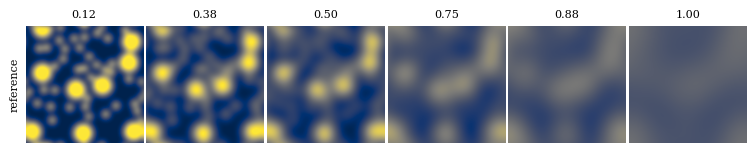

In [59]:
fig, axes = plt.subplots(
    1,
    len(export_times),
    figsize=(panel_inches * len(export_times), panel_inches),
    squeeze=False,
)

for col_idx, (t_value, field) in enumerate(zip(export_times, reference_fields_sample, strict=True)):
    ax = axes[0, col_idx]
    ax.imshow(field, cmap=colormap, origin="lower", vmin=vmin, vmax=vmax)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(f"{float(t_value):.2f}", fontsize=8)
    if col_idx == 0:
        ax.set_ylabel("reference", fontsize=8)
    for spine in ax.spines.values():
        spine.set_visible(False)

fig.subplots_adjust(wspace=strip_gap, hspace=strip_gap)
plt.show()
